Number of features: 16
Number of observations: 4240
datatypes male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object
Number of observations: 4240
Percentage male: 44.36851%
Percentage not male: 55.63149%
Percentage smoker: 51.09349%
Percentage cholt: 45.02460%
diaBP Mean: 82.89776
diaBP Median: 82.00000
sysBP Mean: 132.35460
sysBP Median: 128.00000


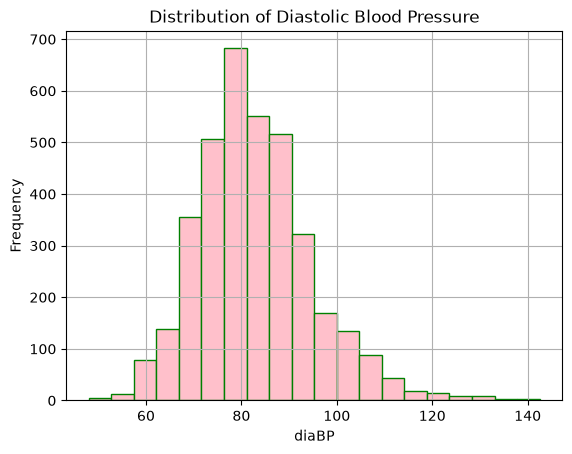

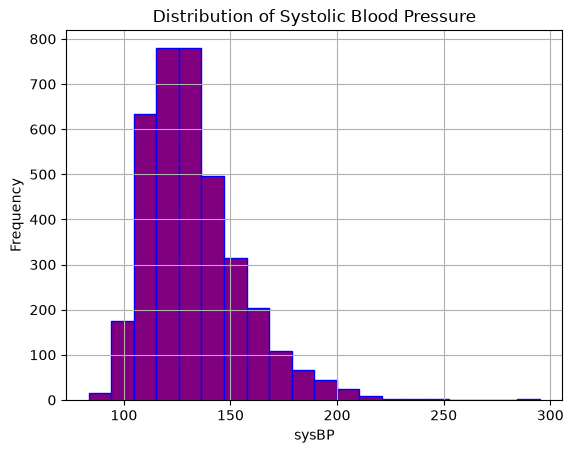

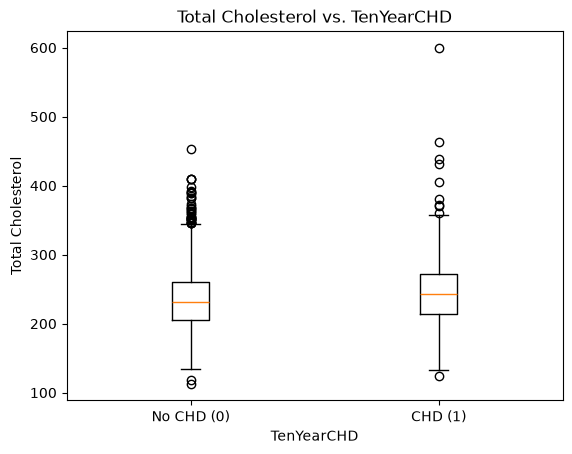

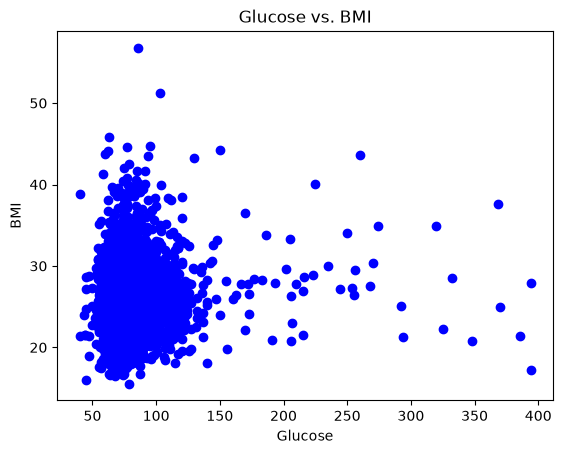

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('framingham.csv')
df.head()

print("Number of features:", len(df.columns))
print("Number of observations:", len(df))
print("datatypes", df.dtypes)

df_clean = pd.DataFrame()
if any(df.isna()):
    df_clean = df.dropna()
df_clean.head()

print("Number of observations:", len(df))

male_percentage = df_clean['male'].value_counts(normalize=True)*100
print(f"Percentage male: {male_percentage[1]:.5f}%")
print(f"Percentage not male: {male_percentage[0]:.5f}%")

smoker_percentage = df_clean['currentSmoker'].value_counts(normalize=True)*100
print(f"Percentage smoker: {smoker_percentage[0]:.5f}%")

chol_percentage = (df_clean['totChol'] >= 240).mean()*100
print(f"Percentage cholt: {chol_percentage:.5f}%")

diaBP_mean = df['diaBP'].mean()
diaBP_median = df['diaBP'].median()

sysBP_mean = df['sysBP'].mean()
sysBP_median = df['sysBP'].median()

print(f"diaBP Mean: {diaBP_mean:.5f}")
print(f"diaBP Median: {diaBP_median:.5f}")
print(f"sysBP Mean: {sysBP_mean:.5f}")
print(f"sysBP Median: {sysBP_median:.5f}")

df_clean['diaBP'].hist(bins=20, color='pink', edgecolor='green')
plt.title("Distribution of Diastolic Blood Pressure")
plt.xlabel("diaBP")
plt.ylabel("Frequency")
plt.show()

df_clean['sysBP'].hist(bins=20, color='purple', edgecolor='blue')
plt.title("Distribution of Systolic Blood Pressure")
plt.xlabel("sysBP")
plt.ylabel("Frequency")
plt.show()

chd_0 = df_clean[df_clean['TenYearCHD'] == 0]['totChol']
chd_1 = df_clean[df_clean['TenYearCHD'] == 1]['totChol']

plt.boxplot([chd_0, chd_1], label=['No CHD (0)', 'CHD (1)'])
plt.title('Total Cholesterol vs. TenYearCHD')
plt.xlabel('TenYearCHD')
plt.ylabel('Total Cholesterol')
plt.xticks([1, 2], ['No CHD (0)', 'CHD (1)'])
plt.show()

plt.scatter(df_clean['glucose'], df_clean['BMI'], color='blue', marker='o')
plt.title("Glucose vs. BMI")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.show()
